### Proyecto: Análisis y Predicción del Precio de las Acciones de Toyota

Objetivo:

Desarrollar un modelo para predecir el precio de cierre ajustado de Toyota basado en datos históricos, analizar tendencias y proporcionar visualizaciones interactivas.

In [170]:
#Importar bibliotecas
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score


In [171]:
#Carga de dataset
df_stock= pd.read_csv('Toyota_data.csv')

In [172]:
print('Primeras filas del dataset')
df_stock.head(5)

Primeras filas del dataset


,Date,Adj Close,Close,High,Low,Open,Volume
0,1980-03-17,2.296798,3.291227,3.344743,3.291227,0.000000,41109
1,1980-03-18,2.306134,3.304606,3.358122,3.304606,0.000000,9343
2,1980-03-19,2.306134,3.304606,3.304606,3.304606,3.304606,0
3,1980-03-20,2.306134,3.304606,3.358122,3.304606,0.000000,10277
4,1980-03-21,2.362154,3.384880,3.438396,3.384880,0.000000,8409


In [173]:
df_stock.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 11291 entries, 0 to 11290
Data columns (total 7 columns):
 #   Column     Non-Null Count  Dtype  
---  ------     --------------  -----  
 0   Date       11291 non-null  object 
 1   Adj Close  11291 non-null  float64
 2   Close      11291 non-null  float64
 3   High       11291 non-null  float64
 4   Low        11291 non-null  float64
 5   Open       11291 non-null  float64
 6   Volume     11291 non-null  int64  
dtypes: float64(5), int64(1), object(1)
memory usage: 617.6+ KB


In [174]:
print('Estadisticas descriptivas')
df_stock.describe()

Estadisticas descriptivas


,Adj Close,Close,High,Low,Open,Volume
count,11291.000000,11291.000000,11291.000000,11291.000000,11291.000000,1.129100e+04
mean,63.586275,72.057776,72.478879,71.646418,67.955424,2.146604e+05
std,52.272225,51.295776,51.552662,50.976716,55.851523,3.874256e+05
min,2.259452,3.237711,3.237711,3.237711,0.000000,0.000000e+00
25%,19.224636,27.548208,27.735613,27.548208,0.000000,1.350000e+04
50%,50.583900,66.040001,66.650002,65.440002,66.000000,9.100000e+04
75%,104.705669,114.295002,114.895000,113.625000,114.294998,2.923000e+05
max,254.770004,254.770004,255.229996,253.589996,255.000000,1.858270e+07


In [175]:
#Convertir columna date a datatime
df_stock['Date']= pd.to_datetime(df_stock['Date'])

In [176]:
df_stock.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 11291 entries, 0 to 11290
Data columns (total 7 columns):
 #   Column     Non-Null Count  Dtype         
---  ------     --------------  -----         
 0   Date       11291 non-null  datetime64[ns]
 1   Adj Close  11291 non-null  float64       
 2   Close      11291 non-null  float64       
 3   High       11291 non-null  float64       
 4   Low        11291 non-null  float64       
 5   Open       11291 non-null  float64       
 6   Volume     11291 non-null  int64         
dtypes: datetime64[ns](1), float64(5), int64(1)
memory usage: 617.6 KB


In [177]:
#Revision de valores nulos
display(df_stock.isna().sum())

Date         0
Adj Close    0
Close        0
High         0
Low          0
Open         0
Volume       0
dtype: int64

In [178]:
#Rango de precios diarios: Diferencia entre el precio mas alto y el mas bajo de un dia 
df_stock['Daily Range'] = df_stock['High'] - df_stock['Low']

In [179]:
#Cambio Diario (%): Porcentaje de cambio en el precio de cierre respecto al día anterior.
df_stock['Daily Change (%)'] = df_stock['Close'].pct_change() * 100

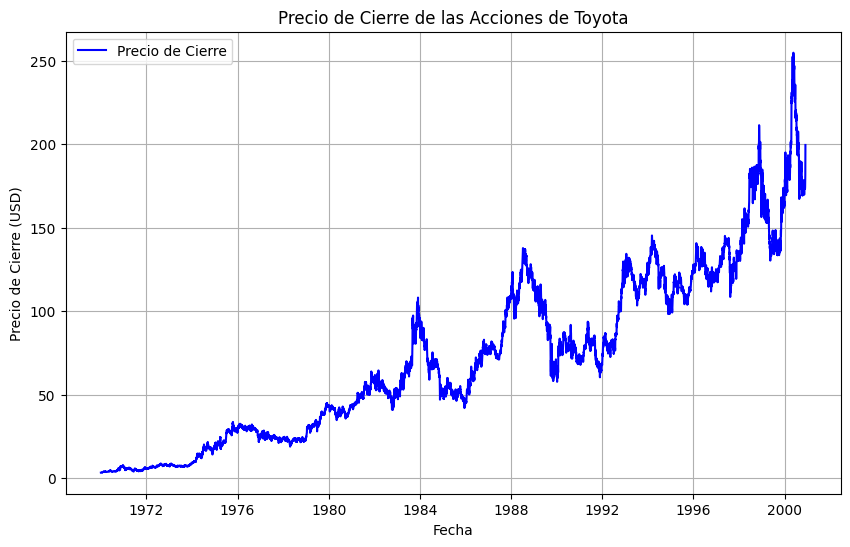

In [180]:
#Grafico de tendencia: precios de cierre (close)
plt.figure(figsize=(10,6))
plt.plot(df_stock.index, df_stock['Close'], label='Precio de Cierre', color='blue')
plt.title('Precio de Cierre de las Acciones de Toyota')
plt.xlabel('Fecha')
plt.ylabel('Precio de Cierre (USD)')
plt.grid(True)
plt.legend()
plt.gca().xaxis_date()

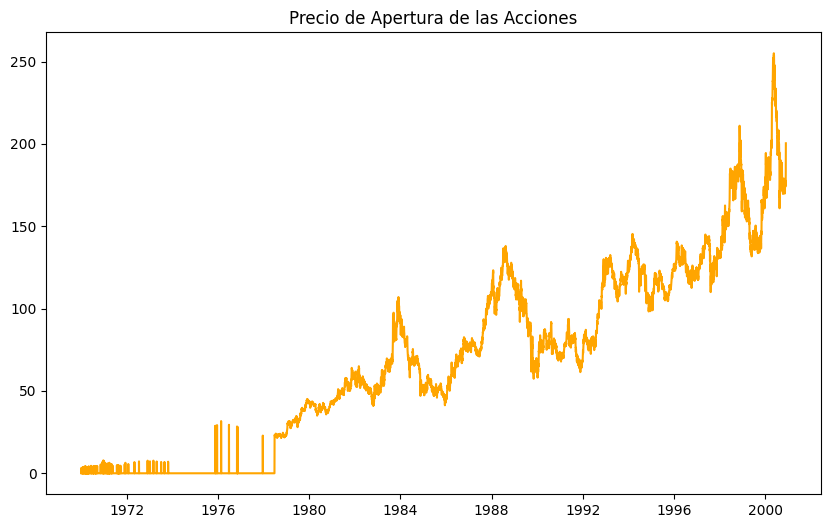

In [181]:
# Graficar el precio de apertura
plt.figure(figsize=(10,6))
plt.plot(df_stock.index, df_stock['Open'], label='Precio de Apertura', color='orange')
plt.title('Precio de Apertura de las Acciones')
plt.gca().xaxis_date()

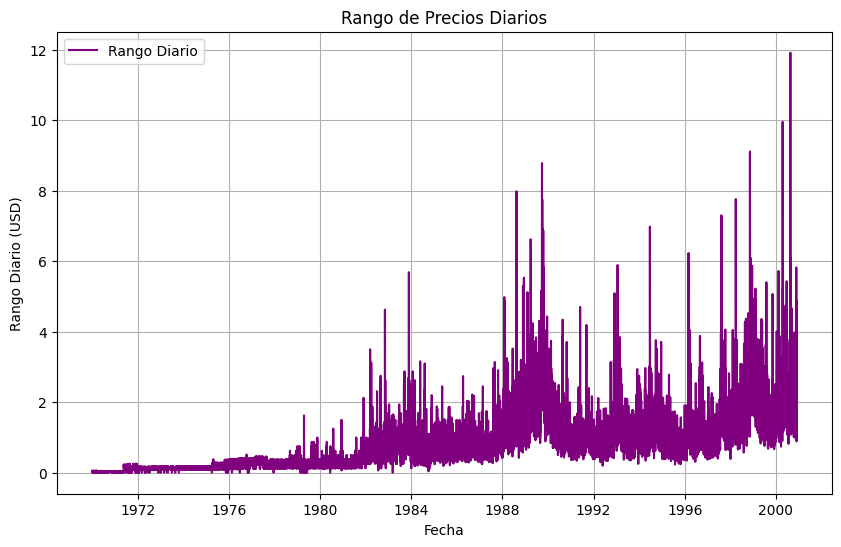

In [182]:
#Grafico de tendencia precios diarios
plt.figure(figsize=(10,6))
plt.plot(df_stock.index, df_stock['Daily Range'], label='Rango Diario', color='purple')
plt.title('Rango de Precios Diarios')
plt.xlabel('Fecha')
plt.ylabel('Rango Diario (USD)')
plt.grid(True)
plt.legend()
plt.gca().xaxis_date()

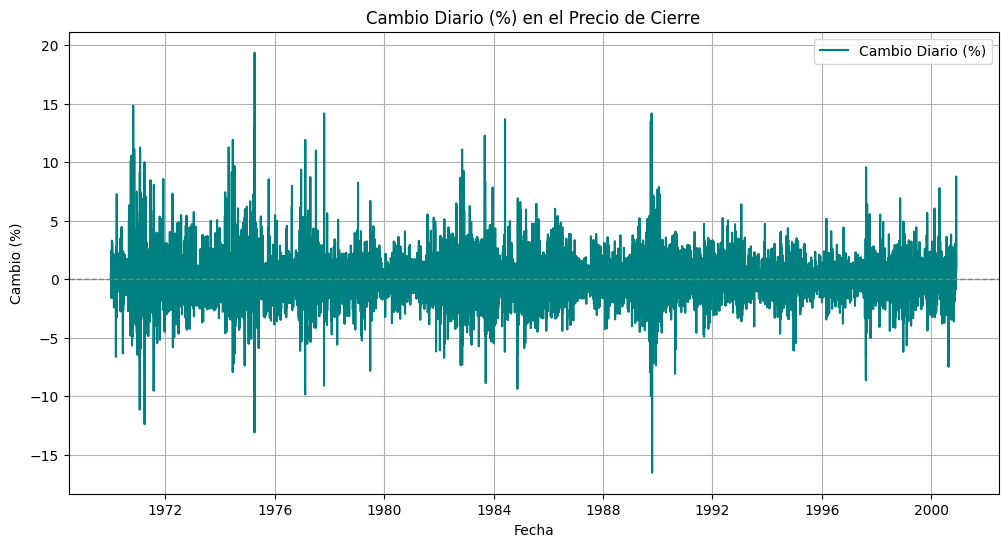

In [183]:
# Graficar el Cambio Diario (%)
plt.figure(figsize=(12,6))
plt.plot(df_stock.index, df_stock['Daily Change (%)'], label='Cambio Diario (%)', color='teal')
plt.axhline(y=0, color='gray', linestyle='--', linewidth=1)  # Línea en y=0 para distinguir cambios positivos y negativos
plt.title('Cambio Diario (%) en el Precio de Cierre')
plt.xlabel('Fecha')
plt.ylabel('Cambio (%)')
plt.grid(True)
plt.legend()
plt.gca().xaxis_date()

## Modelado predictivo

In [184]:
# Definir variables independientes y dependiente
x = df_stock[['Open', 'High', 'Low', 'Volume']].dropna()
y = df_stock['Close']

In [185]:
# Dividir datos
x_train, x_test, y_train, y_test = train_test_split(x, y, test_size=0.2, random_state=42)

### Entrenar el modelo

In [186]:
# Crear y entrenar el modelo
model = LinearRegression()
model.fit(x_train, y_train)

LinearRegression()

In [187]:
# Evaluar en el conjunto de prueba
y_pred = model.predict(x_test)

In [188]:
# Calcular métricas de evaluación
mse = mean_squared_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)

In [189]:
print(f"MSE (Error Cuadrático Medio): {mse:.2f}")
print(f"R2 (Coeficiente de Determinación): {r2:.2f}")

MSE (Error Cuadrático Medio): 0.15
R2 (Coeficiente de Determinación): 1.00


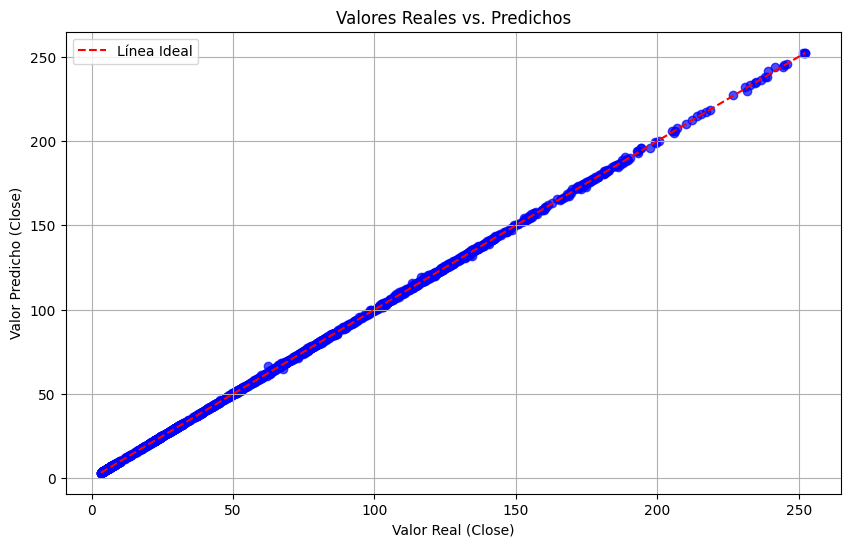

In [190]:
# Comparar valores reales vs. predichos
plt.figure(figsize=(10,6))
plt.scatter(y_test, y_pred, alpha=0.7, color='blue')
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], '--', color='red', label='Línea Ideal')
plt.title('Valores Reales vs. Predichos')
plt.xlabel('Valor Real (Close)')
plt.ylabel('Valor Predicho (Close)')
plt.legend()
plt.grid(True)

## CONCLUSION

En este proyecto, trabajé con un conjunto de datos de los precios de acciones de Toyota para predecir el precio de cierre usando un modelo de regresión lineal. Los resultados obtenidos fueron los siguientes:

MSE (Error Cuadrático Medio): 0.15, lo que significa que el modelo tiene un bajo margen de error en sus predicciones.
R² (Coeficiente de Determinación): 1.00, lo que indica que el modelo ha explicado completamente los datos. Sin embargo, este valor tan alto podría sugerir que el modelo está demasiado ajustado a los datos de entrenamiento.
Lecciones aprendidas:

El modelo funciona bien con los datos de entrenamiento, pero un R² de 1.00 podría indicar un sobreajuste. Esto significa que el modelo podría no funcionar igual de bien con nuevos datos.
Próximos pasos:

Evaluar el modelo con nuevos datos para ver si realmente generaliza bien.
Probar otros modelos o técnicas para mejorar las predicciones.
